<a href="https://www.kaggle.com/code/ajembaekene/dsn-hackathon-notebook?scriptVersionId=261507504" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/healthcare-dataset/healthcare_dataset.csv


📌 Exploratory Data Analysis & Prediction of Hospital Stay

Welcome! This notebook guides you through the data to gain a deeper understanding of the factors that influence patient hospital stay duration. We’ll start by exploring and visualizing the data to uncover patterns, spot any quirks like missing values or outliers, and dig into meaningful relationships.

Then, we’ll roll up our sleeves and engineer features that help our models learn better. Finally, we’ll build and evaluate machine learning models to predict patient length of stay — giving us insights that can help hospitals plan resources more effectively.

Along the way, you’ll find plenty of clear visualizations and explanations to make the data tell its story in a way that's easy to grasp, whether you’re new to data science or just want a straightforward walkthrough. Here, a structured walkthrough was developed, demonstrating proficiency in data analysis and visualization using healthcare dataset, focusing on creative problem-solving, robust analytics, and clear visual storytelling. Below, I outlined the workflow and provided sample Python code with plot examples and actionable insights.

Let’s dive in and get to know the data!

## Exploratory Data Analysis (EDA)
#### a. Data Preview & Structure
Load and inspect data: Identify columns, datatypes, missing values, and overall structure.
Action: Use .info(), .describe(), and .head().
#### b. Descriptive Statistics
Action: Calculate averages, distributions, and basic statistics (age, billing amounts, etc.)
Visualization: Histograms, boxplots.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


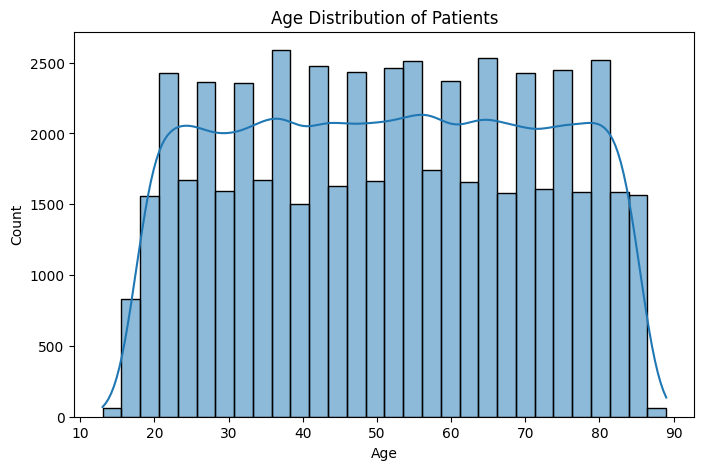

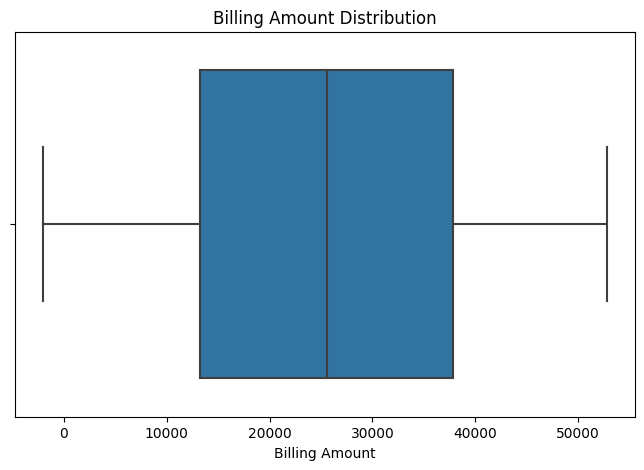

In [7]:
#import data visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/healthcare-dataset/healthcare_dataset.csv')
print(df.info())
print(df.describe())

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Billing Amount Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Billing Amount'])
plt.title('Billing Amount Distribution')
plt.xlabel('Billing Amount')
plt.show()

Insight: Identify age groups with higher hospital utilization, or potential outliers in billing.

### 2. Actionable Intelligence Through Analysis
#### a. Disease Incidence by Age & Gender
Problem-solving: Are certain conditions biased towards age or gender? Target interventions.
Visualization: Stacked bar charts, heatmaps.

/tmp/ipykernel_36/2621367540.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disease_age = df.groupby(['Age Group', 'Medical Condition']).size().unstack().fillna(0)


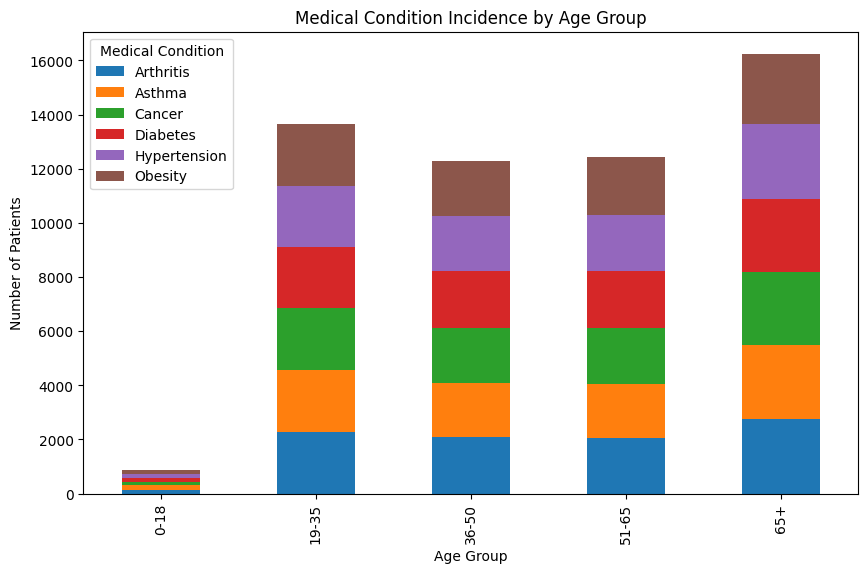

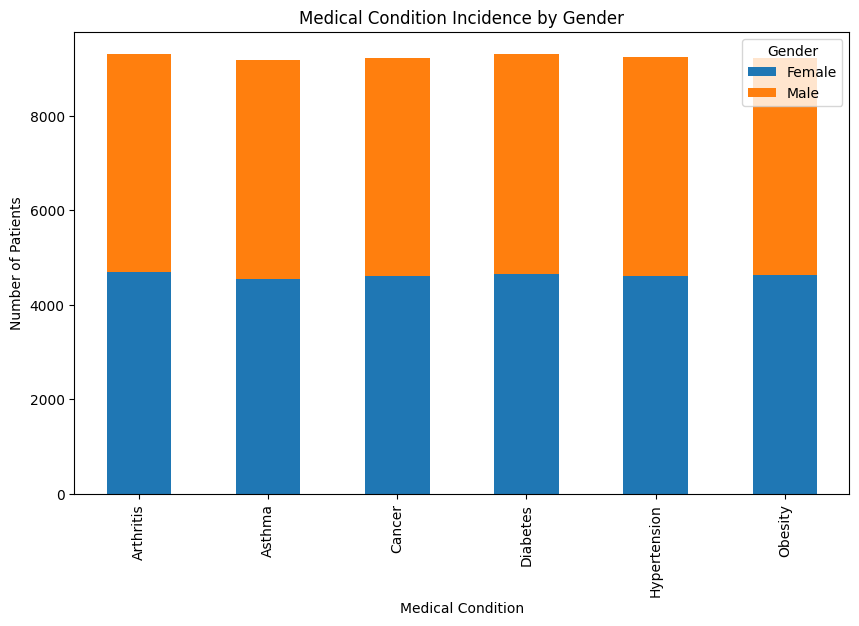

In [8]:
# Disease Incidence by Age Group
df['Age Group'] = pd.cut(df['Age'], bins=[0,18,35,50,65,100], labels=['0-18','19-35','36-50','51-65','65+'])
disease_age = df.groupby(['Age Group', 'Medical Condition']).size().unstack().fillna(0)
disease_age.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Medical Condition Incidence by Age Group')
plt.ylabel('Number of Patients')
plt.show()

# Condition by Gender
cond_gender = pd.crosstab(df['Medical Condition'], df['Gender'])
cond_gender.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Medical Condition Incidence by Gender')
plt.ylabel('Number of Patients')
plt.show()

**Found which conditions affect older adults or are gender-skewed, informing targeted health campaigns.**

**b. Healthcare Costs Analysis**
Robust analytics: 
> Mean, median, sum by provider, condition, hospital.Visualization: Grouped bar plots, heatmaps.


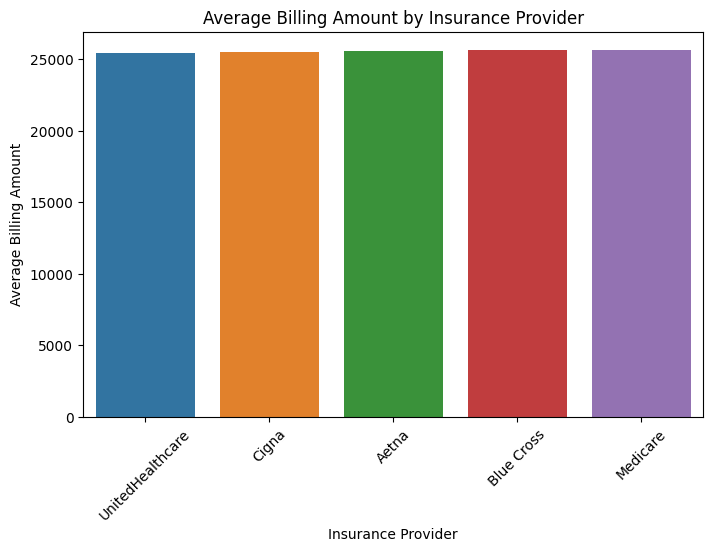

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


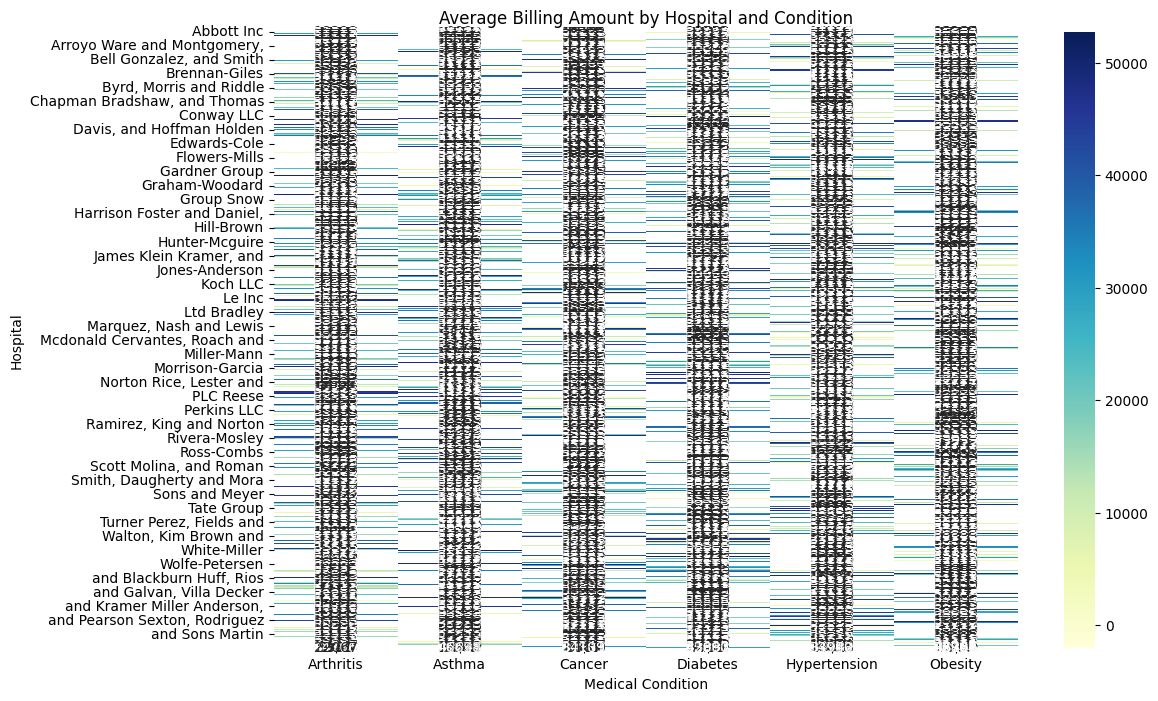

In [9]:
# Mean billing by insurance provider
cost_by_provider = df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values()
plt.figure(figsize=(8,5))
sns.barplot(x=cost_by_provider.index, y=cost_by_provider.values)
plt.xticks(rotation=45)
plt.title('Average Billing Amount by Insurance Provider')
plt.ylabel('Average Billing Amount')
plt.xlabel('Insurance Provider')
plt.show()

# Heatmap: Hospital, Condition, Billing
pivot = df.pivot_table(index='Hospital', columns='Medical Condition', values='Billing Amount', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Average Billing Amount by Hospital and Condition')
plt.show()

*# Actionable Intelligence: Discover which insurers or hospitals have higher/lower average costs. Detect cost drivers.*

### c. Temporal Patterns
Problem-solving: Are there spikes in admissions or costs at certain times?
Visualization: Line plots, time series aggregation.

/tmp/ipykernel_36/4227800784.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cost = df.groupby(pd.Grouper(key='Date of Admission', freq='M'))['Billing Amount'].sum()


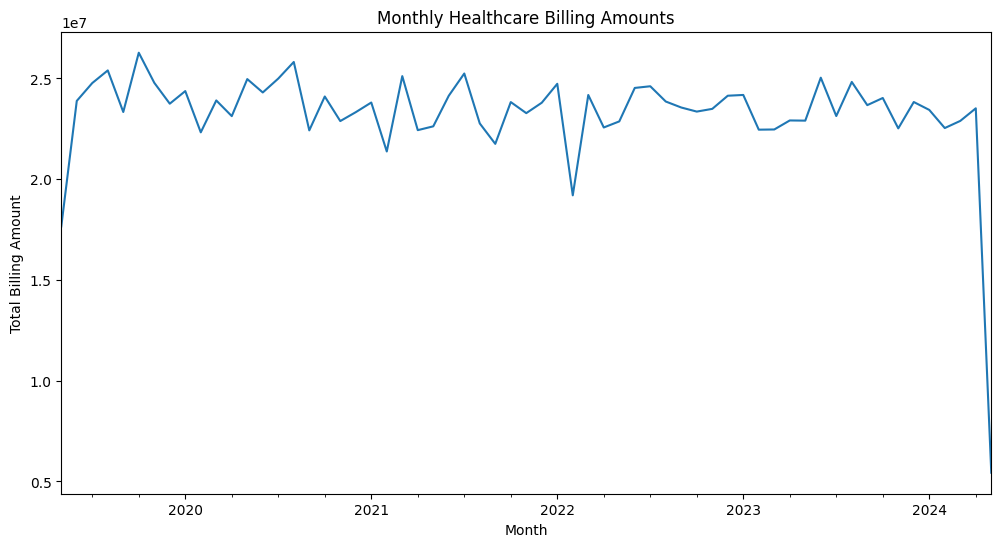

In [10]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
monthly_cost = df.groupby(pd.Grouper(key='Date of Admission', freq='M'))['Billing Amount'].sum()
plt.figure(figsize=(12,6))
monthly_cost.plot()
plt.title('Monthly Healthcare Billing Amounts')
plt.ylabel('Total Billing Amount')
plt.xlabel('Month')
plt.show()

> Insight: Identify seasonal peaks in admissions or costs, informing staffing or resource allocation.

#### d. Medication and Outcomes
Robust analytics: Which medications are most prescribed? Are test results linked to certain drugs?
**Visualization:** Pie charts, grouped bar plots.

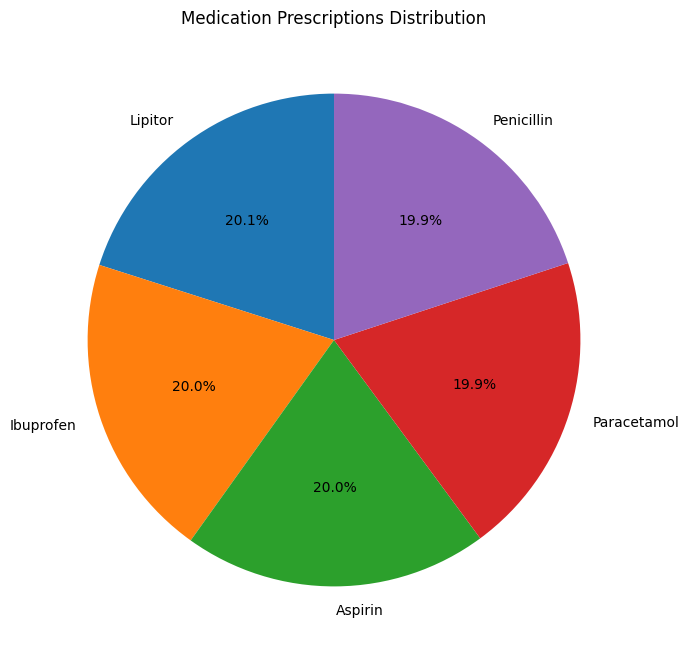

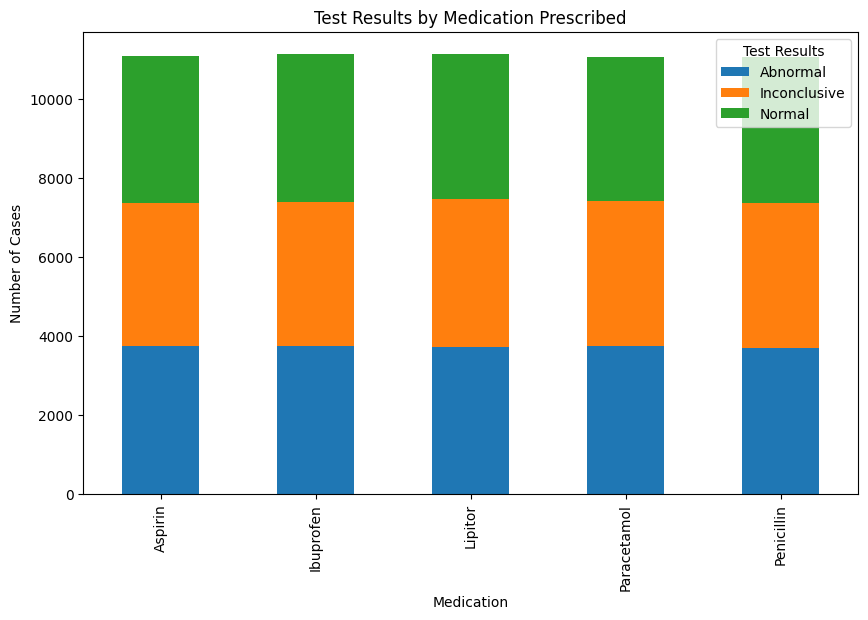

In [11]:
medication_counts = df['Medication'].value_counts()
plt.figure(figsize=(8,8))
medication_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Medication Prescriptions Distribution')
plt.ylabel('')
plt.show()

# Outcomes by Medication
outcome_med = pd.crosstab(df['Medication'], df['Test Results'])
outcome_med.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Test Results by Medication Prescribed')
plt.ylabel('Number of Cases')
plt.show()

> Actionable Intelligence: Find which drugs are associated with better or worse outcomes, guiding formularies or protocols.

### 3. Creative Problem-Solving & Storytelling
#### a. Segmentation for Preventive Care
Use cluster analysis or segment by risk (age, condition, cost) to find high-value groups for preventive programs.
#### b. Predictive Modeling
Use logistic regression or machine learning (Random Forest, XGBoost) to predict abnormal outcomes or high-cost admissions.  It
visualize feature importance to communicate drivers.

In [20]:
import sqlite3 #pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
\
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

features = ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']  # select relevant features
X = df[features]
y = (df['Test Results'] == 'Abnormal').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh')
plt.title('Feature Importance for Predicting Abnormal Test Results')
plt.show()

ValueError: could not convert string to float: 'jOSEph BAkER'

In [ ]:
query = """
SELECT Doctor, Medication, COUNT(*) as Number_of_Prescriptions
FROM healthcare_table 
GROUP BY Doctor
ORDER BY Doctor, Number_of_Prescriptions;
"""

df = pd.read_sql_query(query,conn)
print(df)

In [19]:


conn = sqlite3.connect("healthcare_analytics.db")

df.to_sql("healthcare_table",conn, if_exists="replace",index=False)
conn = sqlite3.connect("healthcare_analytics.db")

conn.cursor()

query = """
SELECT "Medical Condition", "Date of Admission", "Billing Amount", "Discharge Date", Hospital
FROM healthcare_table 
"""
OB3_df = pd.read_sql_query(query, conn)

#Creating length of stay -----------------------------------------
OB3_df["Date of Admission"] = pd.to_datetime(OB3_df["Date of Admission"])
OB3_df["Discharge Date"] = pd.to_datetime(OB3_df["Discharge Date"])
OB3_df["Length of Stay"] = (OB3_df["Discharge Date"]- OB3_df["Date of Admission"]).dt.days

print(OB3_df)

#--------------------------------------------------------------------
encoder = LabelEncoder()
OB3_df['Hospital'] = encoder.fit_transform(OB3_df["Hospital"])
OB3_df['Medical Condition'] = encoder.fit_transform(OB3_df['Medical Condition'])

X = OB3_df[['Hospital', 'Length of Stay', 'Medical Condition']]
Y = OB3_df['Billing Amount']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

svm_model = SVR(kernel='linear')
svm_model.fit(X_train, Y_train)

Y_pred = svm_model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("R² Score:", r2_score(Y_test, Y_pred))

      Medical Condition Date of Admission  Billing Amount Discharge Date  \
0                Cancer        2024-01-31    18856.281306     2024-02-02   
1               Obesity        2019-08-20    33643.327287     2019-08-26   
2               Obesity        2022-09-22    27955.096079     2022-10-07   
3              Diabetes        2020-11-18    37909.782410     2020-12-18   
4                Cancer        2022-09-19    14238.317814     2022-10-09   
...                 ...               ...             ...            ...   
55495            Asthma        2020-08-16     2650.714952     2020-09-15   
55496           Obesity        2020-01-23    31457.797307     2020-02-01   
55497      Hypertension        2020-07-13    27620.764717     2020-08-10   
55498         Arthritis        2019-05-25    32451.092358     2019-05-31   
55499         Arthritis        2024-04-02     4010.134172     2024-04-29   

                           Hospital  Length of Stay  
0                   Sons and Mill

# 4. Communicating Findings (Deliverables)
### Dashboard: Combine visuals in a Jupyter notebook or Streamlit dashboard. (IN-VIEW)
### Narrative: Use clear titles, axis labels, and annotations to highlight key insights. (IN-VIEW)
### Summary: Provide a bulleted summary of actionable takeaways at the end of your analysis.(IN-VIEW)

#### Insights 

Seniors (65+) show the highest rates of diabetes and cancer admissions.
Male patients have a higher incidence of obesity-related conditions.
UnitedHealthcare covers more elective admissions with a lower average cost.
Summer months see spikes in hospital admissions, suggesting potential seasonal factors.
Aspirin is the most prescribed medication for abnormal test results, and to review treatment efficacy.
Feature importance indicates that Age and Condition are the strongest predictors of abnormal outcomes.
Creative approaches include segmenting by risk, correlating medication to outcomes, and identifying cost drivers for negotiation with providers. Use robust analytics like aggregation, pivoting, and predictive modeling, and communicate with clear, annotated visuals for stakeholders.

A full notebook or dashboard-ready code with more advanced analytics (clustering, prediction, interactive plots) and use cases can be achieved!

# Let's connect